In [25]:
from MLPKAN import MLPKAN
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random
from kan import KAN, create_dataset
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

MLPKANmodel = MLPKAN(input_size=2, hidden_sizes=[3], output_size=1, subnetworkshape=[4,4,4])


In [27]:
# f = lambda x: x[:, 0]**2 + x[:, 1]**2
# # f = lambda x: torch.sin(x[:, 0]**2 + 3*x[:, 1])
# # f = lambda x: torch.tanh(torch.exp(x[:, 0] + x[:,1]**4) - (1/x[:,0]))
# # f = lambda x: (1/(x[:, 0]**2 + x[:, 1]**2 + 1)) + x[:, 0]**3 - x[:, 1]**3
# dataset = create_dataset(f, n_var=2, normalize_input=True, seed=seed)

seed = 42
train_path = Path('../../feynmanDataset/train/I.12.1_train.csv')
test_path = Path('../../feynmanDataset/test/I.12.1_test.csv')


train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
X_train = torch.tensor(train_df.iloc[:, :-1].values, dtype=torch.float32)
y_train = torch.tensor(train_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(test_df.iloc[:, :-1].values, dtype=torch.float32)
y_test = torch.tensor(test_df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)
dataset = {'train_input': X_train, 'train_label': y_train, 'test_input': X_test, 'test_label': y_test}

In [28]:
histories = MLPKANmodel.fit(dataset,steps=50, lr=0.001)

Epoch 1/50, RMSE: 0.3216, R2: -0.0025 
Epoch 2/50, RMSE: 0.3212, R2: -0.0000 
Epoch 3/50, RMSE: 0.3212, R2: -0.0001 
Epoch 4/50, RMSE: 0.3215, R2: -0.0019 
Epoch 5/50, RMSE: 0.3212, R2: 0.0001 
Epoch 6/50, RMSE: 0.3214, R2: -0.0007 
Epoch 7/50, RMSE: 0.3269, R2: -0.0353 
Epoch 8/50, RMSE: 0.3178, R2: 0.0211 
Epoch 9/50, RMSE: 0.3054, R2: 0.0963 
Epoch 10/50, RMSE: 0.2703, R2: 0.2918 
Epoch 11/50, RMSE: 0.2182, R2: 0.5384 
Epoch 12/50, RMSE: 0.1961, R2: 0.6275 
Epoch 13/50, RMSE: 0.1813, R2: 0.6816 
Epoch 14/50, RMSE: 0.1701, R2: 0.7196 
Epoch 15/50, RMSE: 0.1601, R2: 0.7515 
Epoch 16/50, RMSE: 0.1543, R2: 0.7694 
Epoch 17/50, RMSE: 0.1501, R2: 0.7817 
Epoch 18/50, RMSE: 0.1453, R2: 0.7954 
Epoch 19/50, RMSE: 0.1446, R2: 0.7974 
Epoch 20/50, RMSE: 0.1428, R2: 0.8025 
Epoch 21/50, RMSE: 0.1415, R2: 0.8061 
Epoch 22/50, RMSE: 0.1371, R2: 0.8179 
Epoch 23/50, RMSE: 0.1357, R2: 0.8214 
Epoch 24/50, RMSE: 0.1296, R2: 0.8371 
Epoch 25/50, RMSE: 0.1218, R2: 0.8563 
Epoch 26/50, RMSE: 0.1120, R

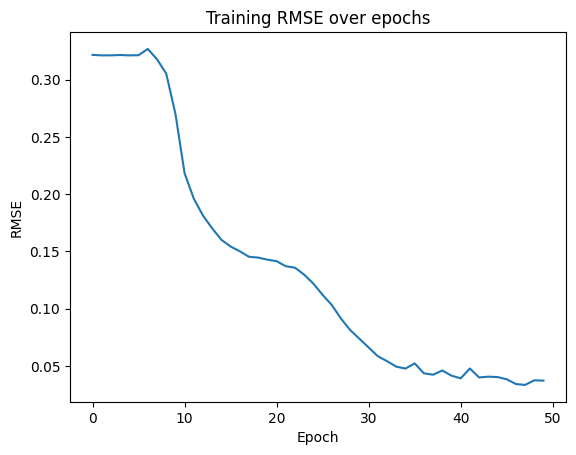

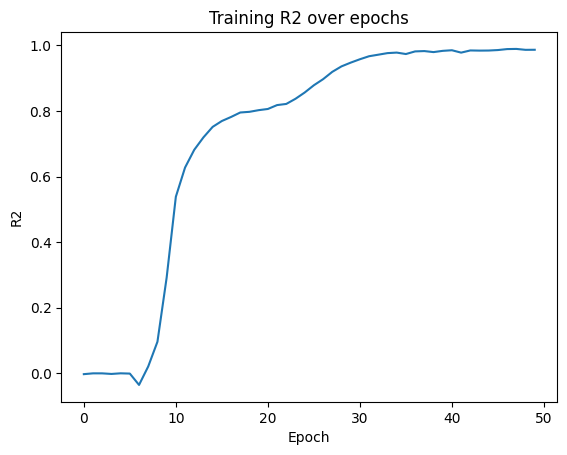

In [29]:
plt.plot(histories['rmse_history'])
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training RMSE over epochs')
plt.show()

plt.plot(histories['R2_history'])
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.title('Training R2 over epochs')
plt.show()


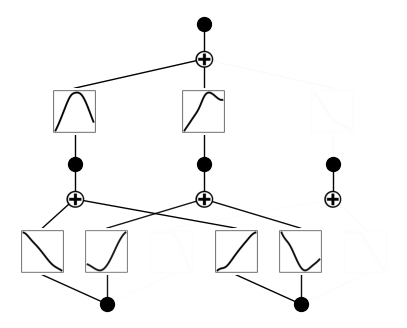

In [30]:
kanmodel = KAN(width=[2,3,1], seed=seed, grid=5, auto_save=False, symbolic_enabled=False)
kanmodel.set_splines_MLPKAN(dataset['train_input'], MLPKANmodel)
kanmodel.plot()

In [31]:
def R2(preds, targets):
            """
            Coefficient of Determination (R²).
            Note: R² can be negative if predictions are worse than the mean baseline.
            R² = 1 - (SS_res / SS_tot)
            """
            pred_mean = torch.mean(preds, dim=0, keepdim=True)
            target_mean = torch.mean(targets, dim=0, keepdim=True)
            SS_res = torch.sum((targets - preds)**2, dim=0)
            SS_tot = torch.sum((targets - target_mean)**2, dim=0)
            r2_score = 1 - (SS_res / (SS_tot + 1e-8))
            return torch.nan_to_num(r2_score)

earlyStop_pred = kanmodel.forward(dataset['train_input'])
R2_score = R2(earlyStop_pred, dataset['train_label']).item()
earlyStop_pred2 = kanmodel.forward(dataset['test_input'])
R2_score2 = R2(earlyStop_pred2, dataset['test_label']).item()
print("R2 score train:", R2_score, "R2 score test:", R2_score2)

R2 score train: 0.9873530864715576 R2 score test: 0.9883878231048584
